# 2.2 Шаблон задания для СР (Занятие 2)

1) Сначала скачайте файл `variant_*.csv` из генератора (HTML-страница).  
2) Загрузите CSV рядом с ноутбуком (в Colab: через кнопку «📁 Файлы» в левой боковом меню. Затем нажмите на кнопку "📤 Загрузить в сессионное хранилище").  
3) В коде ниже замените имя файла `variant_3.csv` на свой вариант и дополняйте строки с `...`.



In [ ]:
# (Необязательно) Colab: загрузка файла variant_*.csv
# from google.colab import files
# files.upload()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# ЗАДАНИЕ: Первичная обработка выборки
# -------------------------------------------------
# ШАГ 0: Загрузите свою выборку (замените номер файла на ваш вариант)
data = np.loadtxt('variant_5.csv', delimiter=',')

n = len(data)

print(data)

print(f"Объём выборки: n = {len(data)}")
print()

# -------------------------------------------------
print('ШАГ 1: Вариационный ряд')
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
sorted_data = sorted(data)
# Выведите первые 5 и последние 5 значений вариационного ряда
for i in range(5):
  print(sorted_data[i])

for i in range(len(data)-5, len(data)):
  print(sorted_data[i])


# print(sorted_data[:5])
# print(sorted_data[-5:])



[86.7 58.7 74.4 55.3 61.8 77.8 50.3 65.8 82.1 78.6 63.6 77.3 74.2 84.9
 77.5 81.2 75.  82.  62.  55.5 67.5 62.6 76.8 77.  79.4 55.3 73.7 59.7
 79.2 59.9 66.6 50.6 79.7 56.9 90.5 80.7 52.3 54.1 83.2 74.8 65.4 60.1
 75.  65.1 86.9 66.5 94.5 77.5 69.  61.8 65.3 82.3 67.2 89.2 64.9 62.5
 64.9 72.9 84.  67.5 84.4 52.5 64.7 66.9 60.1 69.8 58.4 89.5 70.5 87.1
 57.7 62.4 51.8 80.5 69.7 63.1 74.3 91.7 63.3 63.4 76.  71.4 54.6 61.6
 68.3 44.6 71.9 57.2 62.5 47.1 62.1 69.5 68.  90.7 59.2 88.2 78.8 74.1
 81.1 59.7]
Объём выборки: n = 100

ШАГ 1: Вариационный ряд
44.6
47.1
50.3
50.6
51.8
89.5
90.5
90.7
91.7
94.5


In [ ]:


# -------------------------------------------------
# ШАГ 2: Выборочные оценки
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# x_bar = ...       # среднее
# s2 = ...          # дисперсия (несмещённая!)
# s = ...           # стандартное отклонение
# median = ...      # медиана
# x_min = ...       # минимум
# x_max = ...       # максимум

print("Выборочные оценки:")
x_avg=sum(data)/n
print(f"  Среднее:      x̄ = ", x_avg)

sum_s=0
for i in data:
  sum_s+=(i-x_avg)**2
disp=sum_s/(n-1)

stepen = 0.5

print(f"  Дисперсия:    s² = ", disp)
print(f"  Ст. откл.:    s = ", np.float_power(disp, 0.5))


# med = 0
if n % 2 == 0 :
  med = sorted_data[n//2 -1] + sorted_data[n//2]
else:
  med = sorted_data[n//2]

print(f"  Медиана:      x̃ = ", med)

x_min = min(sorted_data)
x_max = max(sorted_data)

print(f"  Размах:       [{x_min:.1f}, {x_max:.1f}]")
print()


Выборочные оценки:
  Среднее:      x̄ =  69.76100000000001
  Дисперсия:    s² =  129.99088787878787
  Ст. откл.:    s =  11.401354651039844
  Медиана:      x̃ =  136.3
  Размах:       [44.6, 94.5]



Правило Скотта:
  Ширина интервала: h = 8.60
  Число интервалов: k = 6



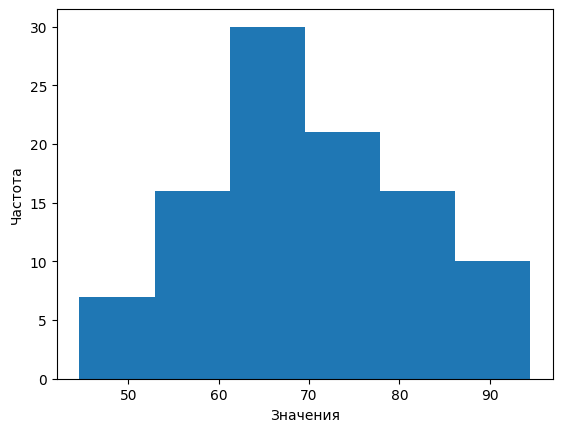

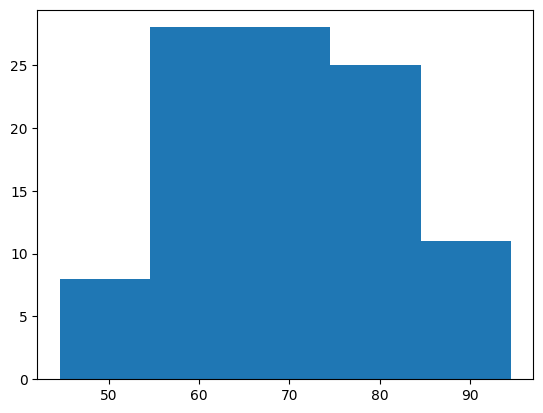

In [ ]:

# -------------------------------------------------
# ШАГ 3: Правило Скотта и гистограмма
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
import math

n = len(data)
s = np.float_power(disp, 0.5)  # уже посчитано в Шаге 2
h = 3.5 * s * n**(-1/3)
k = math.ceil((x_max-x_min) /h)# число интервалов (округлить вверх)

print(f"Правило Скотта:")
print(f"  Ширина интервала: h = {h:.2f}")
print(f"  Число интервалов: k = {k}")
print()

# Постройте ДВЕ гистограммы рядом:
#  а) с числом интервалов по Скотту
#  б) с фиксированным числом интервалов = 5
# Добавьте на каждую вертикальную линию со средним значением


plt.hist(data, bins=k)
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.show()

plt.hist(data, bins=5)
plt.show()

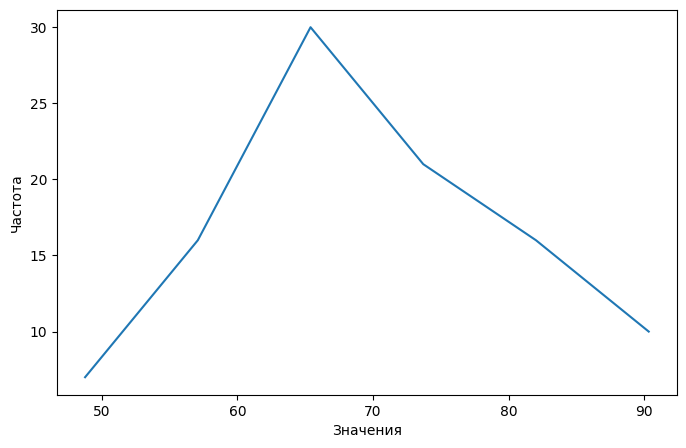

In [ ]:
# -------------------------------------------------
# ШАГ 4: Полигон частот
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# Постройте полигон частот для интервального ряда
# (используйте те же интервалы, что и в гистограмме по Скотту)

hist, bin_edges = np.histogram(data, bins=k)
# середины интервалов
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hist)
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.show()

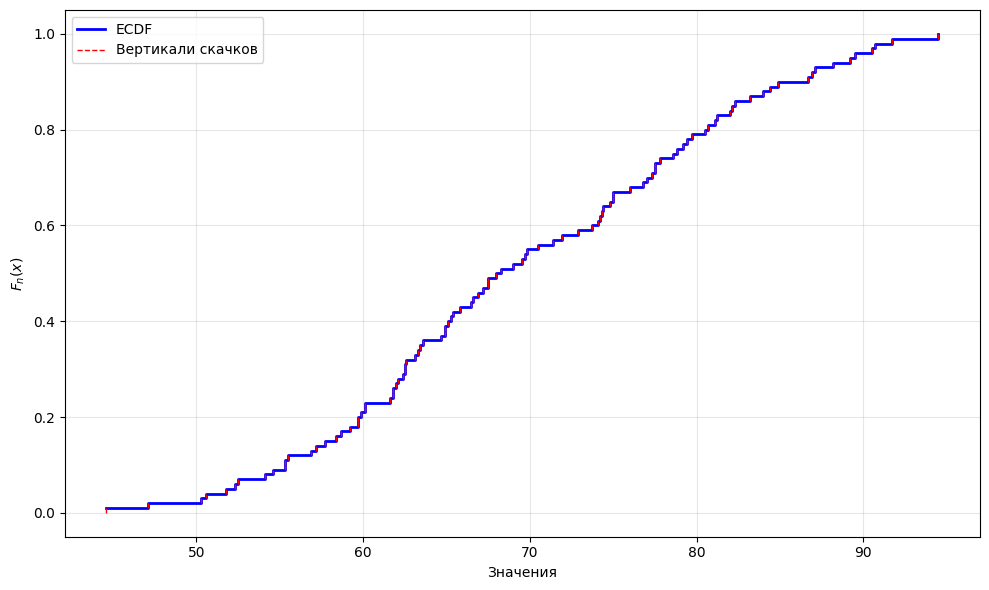

In [ ]:

# -------------------------------------------------
# ШАГ 5: Эмпирическая функция распределения
# -------------------------------------------------
# ДОПОЛНИТЕ КОД:
# Постройте график ЭФР с пунктирными вертикалями в точках скачков
# и точками на горизонтальных участках

y_ecdf = np.arange(1, n + 1) / n
plt.figure(figsize=(10, 6))
x_sorted = sorted_data


plt.step(x_sorted, y_ecdf, where='post', color='blue', linewidth=2, label='ECDF')

# Для первого скачка линия от 0 до 1/n
plt.vlines(x_sorted[0], ymin=0, ymax=y_ecdf[0],
           colors='red', linestyles='dashed', linewidth=1, label='Вертикали скачков')
# Для остальных — от предыдущего уровня до текущего
for i in range(1, n):
    plt.vlines(x_sorted[i], ymin=y_ecdf[i-1], ymax=y_ecdf[i],
               colors='red', linestyles='dashed', linewidth=1)
plt.xlabel('Значения')
plt.ylabel('$F_n(x)$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:

# -------------------------------------------------
# ШАГ 6: Сравнение с истинными параметрами
# -------------------------------------------------
# Истинные параметры вашего варианта:
mu_true = 70   # подставьте μ для вышего варианта
sigma2_true = 121  # подставьте σ² для вышего варианта

print("Сравнение с истинными параметрами:")
print(f"  Истинное μ = {mu_true}, выборочное x̄ = ", x_avg)
print(f"  Истинное σ² = {sigma2_true}, выборочное s² = ", disp)
print()
print("Вопрос: Почему выборочные оценки отличаются от истинных параметров?")


Сравнение с истинными параметрами:
  Истинное μ = 70, выборочное x̄ =  69.76100000000001
  Истинное σ² = 121, выборочное s² =  129.99088787878787

Вопрос: Почему выборочные оценки отличаются от истинных параметров?
